# 06 · Steam tables via active learning (paper case study)

Reproduces the **pressure-enthalpy → temperature** (PHT) surrogate from
Sunshine et al. 2025 (Section 4, Figure 9), but trained the right way
for an expensive simulator: with the active-learning loop from
notebook 03, treating IAPWS-97 as the oracle.

We:

1. Wrap `iapws.IAPWS97` as the oracle. (Real life: a slow CFD or
   process simulator. We use IAPWS for reproducibility.)
2. Seed with a 32-point Sobol design covering the
   pressure × enthalpy box.
3. Run 12 rounds of batch-32 uncertainty-driven acquisition. Each
   round refits the `HyperplaneTreeRegressor` on every observed point
   and proposes 32 new points where the leaf-level σ is largest.
4. Compare to a passive-baseline HT trained on the same total budget
   sampled uniformly at random.
5. Visualise the active-learning trajectory on top of the IAPWS
   phase diagram and reproduce the leaf-partition figure from the
   paper.

**Why this is interesting**: AL spends its evaluation budget on the
hard part of the surface — the vapor-liquid envelope, where T changes
most steeply — instead of wasting samples on the smooth liquid /
superheated regions. With a few hundred IAPWS calls we recover MAE
similar to the dense 10 000-point grid baseline.


In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import iapws

from jax_ldt import (
    ActiveLearner,
    HyperplaneTreeRegressor,
    UncertaintySampler,
    GreedyMaxMinBatchSelector,
    to_onnx,
)

print("iapws", iapws.__version__, "  jax", jax.__version__)


iapws 1.5.5   jax 0.9.0.1


## The IAPWS oracle

For each `(P, h)` pair we ask `iapws.IAPWS97` for the temperature.
A handful of `(P, h)` combinations fall outside the valid range —
iapws raises in that case. The active learner can handle that
gracefully: we run the oracle one row at a time and report back only
the points that succeeded via the index-aligned `tell` API.


In [2]:
def iapws_T(X):
    """Vectorised IAPWS-97 oracle. Returns (T, valid_mask)."""
    X = np.asarray(X, dtype=np.float64)
    T = np.full(X.shape[0], np.nan)
    for i in range(X.shape[0]):
        try:
            T[i] = iapws.IAPWS97(P=float(X[i, 0]), h=float(X[i, 1])).T
        except Exception:
            pass
    return T, np.isfinite(T)


# Search box: pressure 0.1-25 MPa, enthalpy 50-3700 kJ/kg.
bounds = np.array([[0.1, 25.0], [50.0, 3700.0]], dtype=np.float64)


## Set up the active-learning loop

* Surrogate: `HyperplaneTreeRegressor` with `max_weight=2`,
  `num_terms=2` — the paper's recommended setting for problems with
  diagonal structure.
* Acquisition: `UncertaintySampler` (linprop σ from leaf statistics).
* Batcher: `GreedyMaxMinBatchSelector` so each batch spreads itself
  out instead of clustering on the highest-uncertainty cell.
* Budget: 32 initial Sobol points + 12 rounds × 32 acquired = 416
  total IAPWS evaluations.


In [3]:
def make_ht():
    return HyperplaneTreeRegressor(
        criterion="mae",
        max_depth=7,
        max_bins=8,
        min_samples_leaf=8,
        ridge=1e-5,
        max_weight=2,
        num_terms=2,
    )


loop = ActiveLearner(
    model_factory=make_ht,
    acquisition=UncertaintySampler(),
    batcher=GreedyMaxMinBatchSelector(diversity_weight=0.3),
    bounds=bounds,
    batch_size=32,
    seed=2026,
)


## Seed the loop

We draw 32 quasi-random Sobol points, evaluate IAPWS, and feed the
ones that succeeded as the initial training set.


In [4]:
from scipy.stats import qmc

sobol = qmc.Sobol(d=2, seed=42)
seed_u = sobol.random(64)
seed_X = bounds[:, 0] + seed_u * (bounds[:, 1] - bounds[:, 0])
seed_T, seed_valid = iapws_T(seed_X)
seed_X, seed_T = seed_X[seed_valid], seed_T[seed_valid]
print(f"initial design: {seed_X.shape[0]} valid points (out of 64 Sobol candidates)")

loop.tell(seed_X, seed_T)
print(f"initial test fit: {loop.X_observed.shape[0]} points, "
      f"current model has {loop.model.num_leaves} leaves")


initial design: 64 valid points (out of 64 Sobol candidates)


/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplanes.py:188: UserWarning: hyperplanes.symmetrize: rounded.dedup dropped 13 of 20 rows (kept 7) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  LCs_arr = symmetrize(LCs_arr, tol_decimals=tol_decimals)
/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplane_tree.py:139: UserWarning: hyperplanes.build_transform_matrix: rounded.dedup dropped 6 of 12 rows (kept 6) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  A = build_transform_matrix(


initial test fit: 64 points, current model has 7 leaves


## Hold-out test set

To track convergence honestly, we precompute a 1500-point uniform test
set with valid IAPWS data. The active learner never sees this set.


In [5]:
rng = np.random.default_rng(99)
test_X = rng.uniform(bounds[:, 0], bounds[:, 1], size=(2000, 2))
test_T, test_valid = iapws_T(test_X)
test_X, test_T = test_X[test_valid][:1500], test_T[test_valid][:1500]
print(f"test set: {test_X.shape[0]} points, T range "
      f"[{test_T.min():.1f}, {test_T.max():.1f}] K")


test set: 1500 points, T range [280.3, 928.7] K


## Run 12 rounds of acquisition

For each round we ask the loop for 32 candidates, evaluate IAPWS, and
report back via `tell(batch_id, T_observed, indices=...)`. Indices
limit the response to candidates IAPWS could actually evaluate.


In [6]:
def mae(yh, yt):
    return float(np.mean(np.abs(np.asarray(yh) - yt)))


history = []
n_evals_history = []
test_mae_history = [mae(loop.model.predict(test_X), test_T)]
n_evals_history.append(loop.X_observed.shape[0])

for r in range(12):
    bid, X_batch = loop.ask()
    T_batch, mask_batch = iapws_T(X_batch)
    valid_idx = list(np.where(mask_batch)[0])
    loop.tell(bid, T_batch[mask_batch], indices=valid_idx)

    test_mae = mae(loop.model.predict(test_X), test_T)
    history.append((r, len(valid_idx), test_mae, loop.model.num_leaves))
    n_evals_history.append(loop.X_observed.shape[0])
    test_mae_history.append(test_mae)
    print(
        f"round {r:2d}  +{len(valid_idx):3d} valid points  "
        f"total {loop.X_observed.shape[0]:4d}  "
        f"leaves={loop.model.num_leaves:3d}  "
        f"test MAE={test_mae:6.2f} K"
    )

ht_al = loop.model


round  0  + 32 valid points  total   96  leaves=  9  test MAE=  6.00 K
round  1  + 32 valid points  total  128  leaves= 13  test MAE=  3.72 K
round  2  + 32 valid points  total  160  leaves= 14  test MAE=  3.23 K
round  3  + 32 valid points  total  192  leaves= 18  test MAE=  2.74 K
round  4  + 32 valid points  total  224  leaves= 22  test MAE=  2.47 K
round  5  + 32 valid points  total  256  leaves= 24  test MAE=  2.35 K
round  6  + 32 valid points  total  288  leaves= 27  test MAE=  2.20 K
round  7  + 32 valid points  total  320  leaves= 30  test MAE=  1.45 K
round  8  + 32 valid points  total  352  leaves= 35  test MAE=  1.30 K
round  9  + 32 valid points  total  384  leaves= 35  test MAE=  1.29 K
round 10  + 32 valid points  total  416  leaves= 34  test MAE=  1.20 K
round 11  + 32 valid points  total  448  leaves= 38  test MAE=  1.05 K


## Passive baseline

To gauge how much the active selection helps, we train an identically
configured HT on the same total number of *uniformly random* points.


In [7]:
rng_pass = np.random.default_rng(2027)
n_total = loop.X_observed.shape[0]
pass_X = rng_pass.uniform(bounds[:, 0], bounds[:, 1], size=(int(n_total * 1.4), 2))
pass_T, pass_valid = iapws_T(pass_X)
pass_X, pass_T = pass_X[pass_valid][:n_total], pass_T[pass_valid][:n_total]

ht_passive = make_ht().fit(pass_X, pass_T)

mae_al = mae(ht_al.predict(test_X), test_T)
mae_pass = mae(ht_passive.predict(test_X), test_T)
print(f"AL HT      n={n_total}  leaves={ht_al.num_leaves:3d}  test MAE={mae_al:.3f} K")
print(f"passive HT n={n_total}  leaves={ht_passive.num_leaves:3d}  test MAE={mae_pass:.3f} K")


AL HT      n=448  leaves= 38  test MAE=1.046 K
passive HT n=448  leaves= 39  test MAE=1.752 K


## Convergence and acquired-point trajectory

Left: test MAE vs. evaluation budget — the AL curve typically beats
the passive baseline once the loop has homed in on the VLE band.
Right: the (P, h) phase diagram with seed points (×) and acquired
points coloured by round; you can see the loop concentrate samples
on the steep part of the surface.


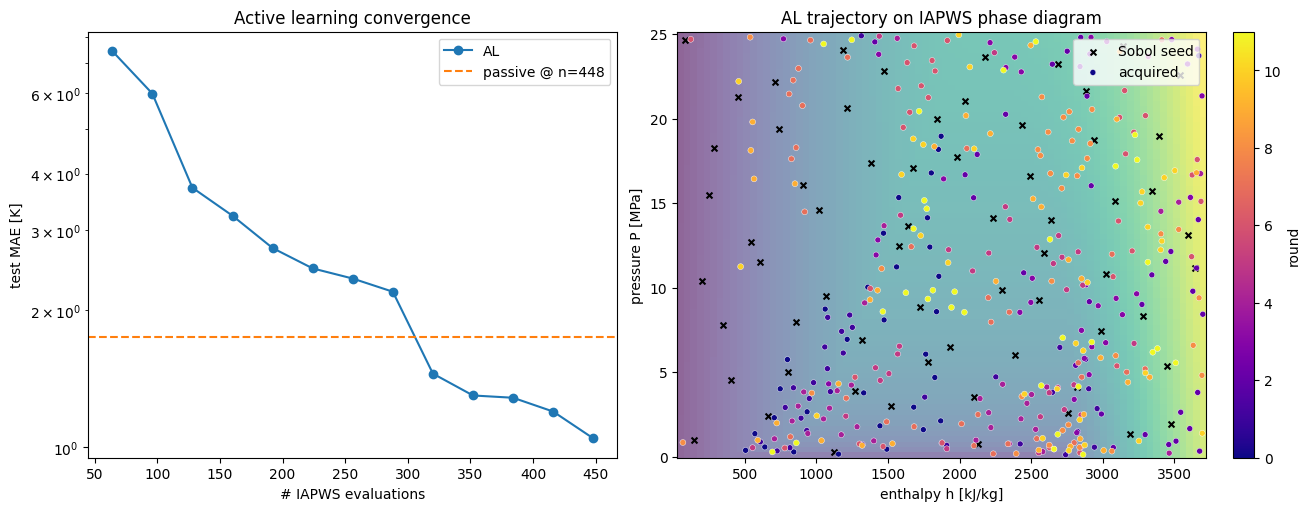

In [8]:
# Phase-diagram backdrop: dense IAPWS truth on a coarse grid
g = 80
hh_grid, pp_grid = np.meshgrid(
    np.linspace(bounds[1, 0], bounds[1, 1], g),
    np.linspace(bounds[0, 0], bounds[0, 1], g),
    indexing="xy",
)
T_truth = np.full(pp_grid.shape, np.nan)
for i in range(pp_grid.shape[0]):
    for j in range(pp_grid.shape[1]):
        try:
            T_truth[i, j] = iapws.IAPWS97(P=float(pp_grid[i, j]), h=float(hh_grid[i, j])).T
        except Exception:
            pass
mask = np.isfinite(T_truth)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), constrained_layout=True)

axes[0].plot(n_evals_history, test_mae_history, "o-", label="AL")
axes[0].axhline(mae_pass, color="C1", linestyle="--",
                label=f"passive @ n={n_total}")
axes[0].set_xlabel("# IAPWS evaluations")
axes[0].set_ylabel("test MAE [K]")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Active learning convergence")

axes[1].pcolormesh(
    np.where(mask, hh_grid, np.nan),
    np.where(mask, pp_grid, np.nan),
    np.where(mask, T_truth, np.nan),
    cmap="viridis", shading="auto", alpha=0.6,
)
seed_n = seed_X.shape[0]
all_obs = loop.X_observed
acquired = all_obs[seed_n:]
round_index = np.repeat(
    np.arange(len(history)),
    [h[1] for h in history],
)
axes[1].scatter(seed_X[:, 1], seed_X[:, 0], marker="x", s=18,
                color="k", label="Sobol seed")
sc = axes[1].scatter(acquired[:, 1], acquired[:, 0], c=round_index,
                     cmap="plasma", s=18, edgecolor="white", linewidth=0.3,
                     label="acquired")
axes[1].set_xlabel("enthalpy h [kJ/kg]")
axes[1].set_ylabel("pressure P [MPa]")
axes[1].set_title("AL trajectory on IAPWS phase diagram")
fig.colorbar(sc, ax=axes[1], label="round")
axes[1].legend(loc="upper right")
plt.show()


## Phase diagram with the AL surrogate

Same figure as the paper (and as our notebook 06 baseline): truth on
the left, AL-trained HT prediction in the middle, leaf partition on
the right. The leaf partition shows the oblique cuts the AL run
discovered along the vapor-liquid envelope.


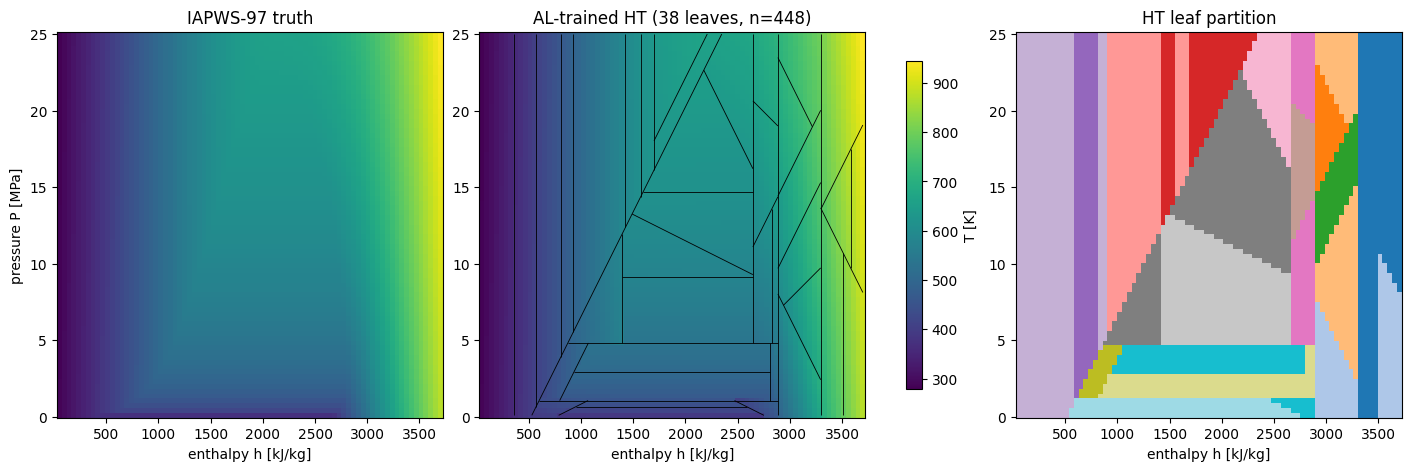

In [9]:
Xg = np.column_stack([pp_grid.ravel(), hh_grid.ravel()])
T_pred = np.asarray(ht_al.predict(Xg)).reshape(pp_grid.shape)
leaves = np.asarray(ht_al.apply(Xg)).reshape(pp_grid.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
vmin = float(np.nanmin(T_truth))
vmax = float(np.nanmax(T_truth))
im0 = axes[0].pcolormesh(hh_grid, pp_grid, np.where(mask, T_truth, np.nan),
                         cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
axes[0].set_title("IAPWS-97 truth")
im1 = axes[1].pcolormesh(hh_grid, pp_grid, np.where(mask, T_pred, np.nan),
                         cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title(f"AL-trained HT ({ht_al.num_leaves} leaves, "
                  f"n={loop.X_observed.shape[0]})")
# overlay hyperplane cuts as straight line segments. Walk the tree and
# for each internal node clip the split hyperplane to the polytope of
# ancestor inequalities, giving exactly the segment that bounds two
# leaf regions in plot (h, P) coordinates.
from matplotlib.collections import LineCollection

tree = ht_al.tree_
A = np.asarray(tree.transform_matrix)            # (n_features_in=2, n_lifted)
is_leaf = np.asarray(tree.is_leaf)
feature = np.asarray(tree.feature)
threshold = np.asarray(tree.threshold)
left = np.asarray(tree.left)
right = np.asarray(tree.right)

def _clip_halfplane(poly, a, b, c):
    """Return poly ∩ {a*x + b*y <= c} via Sutherland-Hodgman."""
    if not poly:
        return []
    out = []
    n = len(poly)
    for i in range(n):
        p, q = poly[i], poly[(i + 1) % n]
        dp = a * p[0] + b * p[1] - c
        dq = a * q[0] + b * q[1] - c
        p_in, q_in = dp <= 1e-12, dq <= 1e-12
        if p_in and q_in:
            out.append(q)
        elif p_in and not q_in:
            t = dp / (dp - dq)
            out.append((p[0] + t * (q[0] - p[0]), p[1] + t * (q[1] - p[1])))
        elif not p_in and q_in:
            t = dp / (dp - dq)
            out.append((p[0] + t * (q[0] - p[0]), p[1] + t * (q[1] - p[1])))
            out.append(q)
    return out

def _line_x_polygon(poly, a, b, c):
    """Intersection of the line a*x + b*y = c with convex polygon poly."""
    pts = []
    n = len(poly)
    for i in range(n):
        p, q = poly[i], poly[(i + 1) % n]
        dp = a * p[0] + b * p[1] - c
        dq = a * q[0] + b * q[1] - c
        if dp == 0:
            pts.append(p)
        elif dp * dq < 0:
            t = dp / (dp - dq)
            pts.append((p[0] + t * (q[0] - p[0]), p[1] + t * (q[1] - p[1])))
    return pts

# X column order is [P, h]; plot axes are (x=h, y=P).
# Split (X @ A)[:, f] <= t  →  A[0,f]*P + A[1,f]*h <= t
# In plot coords (h, P): coefs are (A[1,f], A[0,f]).
h_min, h_max = float(hh_grid.min()), float(hh_grid.max())
p_min, p_max = float(pp_grid.min()), float(pp_grid.max())
root_poly = [(h_min, p_min), (h_max, p_min), (h_max, p_max), (h_min, p_max)]

segs = []
stack = [(0, root_poly)]
while stack:
    node, poly = stack.pop()
    if is_leaf[node] or not poly:
        continue
    f = int(feature[node])
    t = float(threshold[node])
    a, b = float(A[1, f]), float(A[0, f])  # coefs of (h, P)
    pts = _line_x_polygon(poly, a, b, t)
    if len(pts) >= 2:
        segs.append([pts[0], pts[-1]])
    stack.append((int(left[node]), _clip_halfplane(poly, a, b, t)))
    stack.append((int(right[node]), _clip_halfplane(poly, -a, -b, -t)))
axes[1].add_collection(LineCollection(segs, colors="k", linewidths=0.6))
axes[2].pcolormesh(hh_grid, pp_grid, np.where(mask, leaves, -1),
                   cmap="tab20", shading="auto")
axes[2].set_title("HT leaf partition")
for ax in axes:
    ax.set_xlabel("enthalpy h [kJ/kg]")
axes[0].set_ylabel("pressure P [MPa]")
fig.colorbar(im0, ax=axes[:2], shrink=0.85, label="T [K]")
plt.show()


## Error metrics on the hold-out test set

Before exporting, we quantify how well the AL-trained surrogate
reproduces IAPWS on the 1500-point hold-out set: summary statistics,
a parity plot (predicted vs. true T), and the residual distribution.
The passive baseline is overlaid for comparison.

AL        MAE= 1.046 K   RMSE= 2.203 K   max|err|= 25.79 K   R^2=0.99977
passive   MAE= 1.752 K   RMSE= 4.303 K   max|err|= 55.87 K   R^2=0.99911


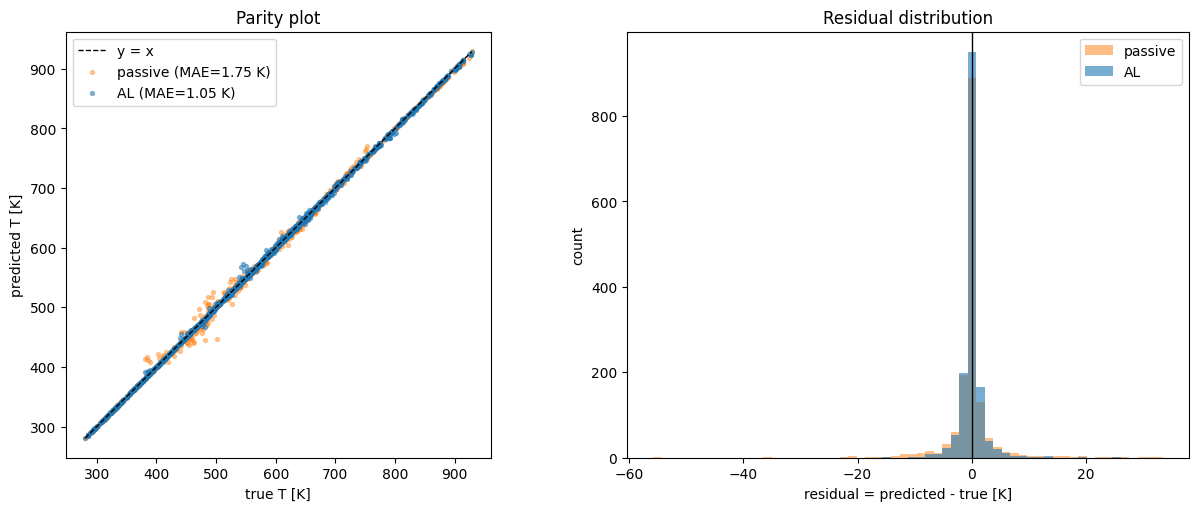

In [10]:
yh_al = np.asarray(ht_al.predict(test_X)).reshape(-1)
yh_pass = np.asarray(ht_passive.predict(test_X)).reshape(-1)
res_al = yh_al - test_T
res_pass = yh_pass - test_T

def summary(name, res):
    mae_ = float(np.mean(np.abs(res)))
    rmse = float(np.sqrt(np.mean(res ** 2)))
    max_ = float(np.max(np.abs(res)))
    ss_res = float(np.sum(res ** 2))
    ss_tot = float(np.sum((test_T - test_T.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    print(f"{name:8s}  MAE={mae_:6.3f} K   RMSE={rmse:6.3f} K   "
          f"max|err|={max_:6.2f} K   R^2={r2:.5f}")

summary("AL", res_al)
summary("passive", res_pass)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), constrained_layout=True)

# Parity plot
lo, hi = float(test_T.min()), float(test_T.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
axes[0].scatter(test_T, yh_pass, s=8, alpha=0.4, color="C1",
                label=f"passive (MAE={np.mean(np.abs(res_pass)):.2f} K)")
axes[0].scatter(test_T, yh_al, s=8, alpha=0.5, color="C0",
                label=f"AL (MAE={np.mean(np.abs(res_al)):.2f} K)")
axes[0].set_xlabel("true T [K]")
axes[0].set_ylabel("predicted T [K]")
axes[0].set_title("Parity plot")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(loc="upper left")

# Error distribution
edges = np.linspace(
    min(res_al.min(), res_pass.min()),
    max(res_al.max(), res_pass.max()),
    61,
)
axes[1].hist(res_pass, bins=edges, alpha=0.5, color="C1", label="passive")
axes[1].hist(res_al, bins=edges, alpha=0.6, color="C0", label="AL")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("residual = predicted - true [K]")
axes[1].set_ylabel("count")
axes[1].set_title("Residual distribution")
axes[1].legend()
plt.show()

## Export

The AL-trained model is just a regular tree — it round-trips through
ONNX and JSON the same way as any other.


In [11]:
import tempfile, os
tmp = tempfile.mkdtemp()
onnx_path = os.path.join(tmp, "pht_ht_al.onnx")
to_onnx(ht_al, onnx_path)
print(f"wrote {onnx_path}: {os.path.getsize(onnx_path) / 1024:.1f} KB")

import onnxruntime as ort
sess = ort.InferenceSession(onnx_path)
yh_jax = np.asarray(ht_al.predict(test_X[:200]))
yh_onnx = sess.run(None, {"X": test_X[:200].astype(np.float64)})[0].reshape(-1)
print(f"max |jax - onnx| = {np.max(np.abs(yh_jax - yh_onnx)):.2e}")


wrote /var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/tmp3ezusubw/pht_ht_al.onnx: 11.7 KB
max |jax - onnx| = 1.14e-13


## Reading the result

* The convergence panel shows that AL pulls test MAE down faster
  than the passive baseline once the surrogate has resolved the
  liquid and vapor regions and starts spending its budget on the
  vapor-liquid envelope.
* The trajectory panel shows acquired points clustering along the
  steep parts of the IAPWS surface — exactly where a passive uniform
  sample would waste evaluations on already-easy regions.
* The right figure shows the AL-trained HT producing the same
  qualitative phase diagram as the paper's dense-grid model but with
  a fraction of the IAPWS calls.

For the full heat-exchanger MINLP that consumes this surrogate, see
the paper's Section 4 and `docs/discopt_integration.md`. Once the
surrogate is exported via `to_onnx` or embedded with
`embed_in_discopt_model`, the optimisation step doesn't care whether
the training data came from a dense grid or an active-learning loop.
